# Q3 Retail Promotions — Feature Engineering & Regression Pipeline

**Objective:** Build a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv('q3_retail_promotions.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1200, 9)


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


---
## Task 1 — Date Feature Engineering
Extract temporal features from `transaction_date` and create the binary `is_month_end` flag.

In [2]:
# Parse transaction_date as datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract year, month, day_of_week
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek   # 0 = Monday … 6 = Sunday

# Binary flag: is_month_end — 1 if day-of-month ≥ 25, else 0
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Confirm new columns
print('New columns added:', ['year', 'month', 'day_of_week', 'is_month_end'])
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(10, random_state=42)

New columns added: ['year', 'month', 'day_of_week', 'is_month_end']


,transaction_date,year,month,day_of_week,is_month_end
1178,2024-12-10,2024,12,1,0
865,2024-03-25,2024,3,0,1
101,2022-03-19,2022,3,5,0
439,2023-02-24,2023,2,4,0
58,2022-02-09,2022,2,2,0
1120,2024-10-21,2024,10,0,0
323,2022-10-23,2022,10,6,0
974,2024-06-24,2024,6,0,0
411,2023-01-31,2023,1,1,1
855,2024-03-16,2024,3,5,0


---
## Task 2 — Temporal Train-Test Split

In [3]:
# Sort chronologically
df = df.sort_values('transaction_date').reset_index(drop=True)

# 80 / 20 temporal split
split_idx = int(len(df) * 0.80)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

print(f'Total records : {len(df)}')
print(f'Train records : {len(train_df)}  ({len(train_df)/len(df):.0%})')
print(f'Test  records : {len(test_df)}  ({len(test_df)/len(df):.0%})')
print(f'Train date range : {train_df["transaction_date"].min().date()} → {train_df["transaction_date"].max().date()}')
print(f'Test  date range : {test_df["transaction_date"].min().date()} → {test_df["transaction_date"].max().date()}')

Total records : 1200
Train records : 960  (80%)
Test  records : 240  (20%)
Train date range : 2022-01-01 → 2024-06-11
Test  date range : 2024-06-12 → 2024-12-31


### Why a random split is inappropriate for time-ordered data

A random split **leaks future information into the training set**. When observations are ordered in time, a random split can place records from later dates in the training fold and earlier dates in the test fold. The model then trains on data it would never have seen in a real deployment scenario, causing the model to *see the future* and artificially inflating evaluation metrics.

Additionally, retail sales data exhibits **temporal autocorrelation** — sales on a given day are correlated with nearby days (seasonality, promotions, trends). Random sampling breaks this structure, so the test set no longer represents the true out-of-sample generalization the model will face when deployed.

A **chronological split** (train on the past, test on the future) mirrors real production conditions and gives an honest estimate of model performance.

---
## Task 3 — Preprocessing Pipeline

In [4]:
# Define feature groups
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                        'year', 'month', 'day_of_week', 'is_month_end']
target               = 'items_sold'

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ],
    remainder='drop'
)

# Prepare X / y
X_train = train_df[categorical_features + numerical_features]
y_train = train_df[target]
X_test  = test_df[categorical_features + numerical_features]
y_test  = test_df[target]

print('Preprocessing pipeline defined.')
print(f'  Categorical columns  → OneHotEncoder : {categorical_features}')
print(f'  Numerical columns    → StandardScaler: {numerical_features}')
print('Pipeline will be fit ONLY on the training set.')

Preprocessing pipeline defined.
  Categorical columns  → OneHotEncoder : ['promotion_type', 'location_type', 'store_size']
  Numerical columns    → StandardScaler: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
Pipeline will be fit ONLY on the training set.


---
## Task 4 — Model Training and Evaluation

In [5]:
# ── 4a. Build and fit pipelines ───────────────────────────────────────────────

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

# Fit on training data only
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print('Both pipelines fitted on training data.')

Both pipelines fitted on training data.


In [6]:
# ── 4b. Predictions ───────────────────────────────────────────────────────────
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# ── 4c. Metrics ───────────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'{model_name:30s}  RMSE = {rmse:7.3f}   MAE = {mae:7.3f}')
    return rmse, mae

print(f'{"Model":<30}  {"RMSE":>10}   {"MAE":>10}')
print('-' * 55)
lr_rmse, lr_mae = evaluate(y_test, y_pred_lr, 'Linear Regression')
rf_rmse, rf_mae = evaluate(y_test, y_pred_rf, 'Random Forest Regressor')

Model                                 RMSE          MAE
-------------------------------------------------------
Linear Regression               RMSE =  27.121   MAE =  21.053
Random Forest Regressor         RMSE =  30.736   MAE =  24.218


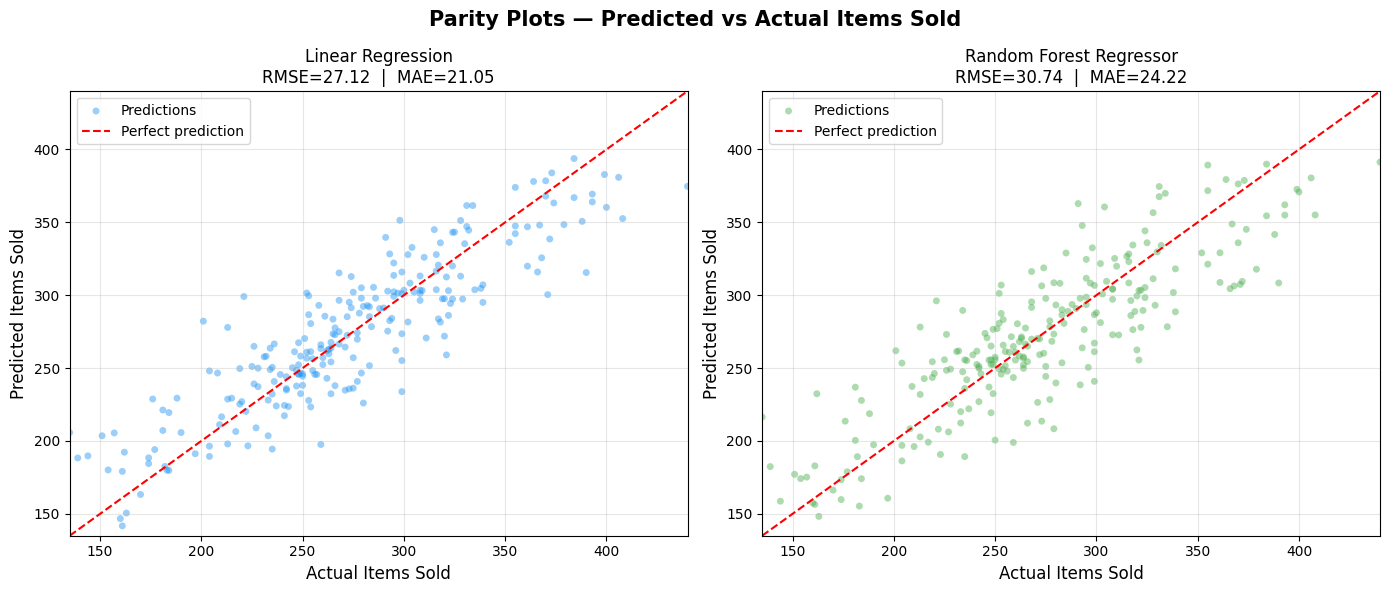

Parity plots saved to parity_plots.png


In [7]:
# ── 4d. Parity Plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Parity Plots — Predicted vs Actual Items Sold', fontsize=15, fontweight='bold')

plot_configs = [
    (axes[0], y_pred_lr, 'Linear Regression',       '#2196F3', lr_rmse, lr_mae),
    (axes[1], y_pred_rf, 'Random Forest Regressor',  '#4CAF50', rf_rmse, rf_mae),
]

for ax, y_pred, title, color, rmse, mae in plot_configs:
    ax.scatter(y_test, y_pred, alpha=0.45, color=color, edgecolors='none', s=25, label='Predictions')
    
    # Diagonal reference line (perfect prediction)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    
    ax.set_xlabel('Actual Items Sold', fontsize=12)
    ax.set_ylabel('Predicted Items Sold', fontsize=12)
    ax.set_title(f'{title}\nRMSE={rmse:.2f}  |  MAE={mae:.2f}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.savefig('parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Parity plots saved to parity_plots.png')

In [8]:
# ── 4e. Feature Importances from Random Forest ────────────────────────────────

# Reconstruct feature names after preprocessing
ohe         = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_names   = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = cat_names + numerical_features

importances   = rf_pipeline.named_steps['model'].feature_importances_
feat_imp_df   = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df   = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

print('All feature importances (Random Forest):')
print(feat_imp_df.to_string(index=False))

print('\n── Top 5 Most Influential Features ────────────────────')
top5 = feat_imp_df.head(5)
for i, row in top5.iterrows():
    print(f'  {i+1}. {row["feature"]:<30}  importance = {row["importance"]:.4f}')

All feature importances (Random Forest):
                      feature  importance
                  is_festival    0.176205
             store_size_small    0.163296
          location_type_urban    0.112267
                  day_of_week    0.085424
                   is_weekend    0.063098
                     store_id    0.054079
          location_type_rural    0.053011
             store_size_large    0.052743
          competition_density    0.050145
                        month    0.037604
          promotion_type_bogo    0.030804
            store_size_medium    0.026419
promotion_type_loyalty_points    0.022642
                         year    0.016408
 promotion_type_flat_discount    0.016390
     location_type_semi-urban    0.016154
promotion_type_category_offer    0.010361
     promotion_type_free_gift    0.007632
                 is_month_end    0.005319

── Top 5 Most Influential Features ────────────────────
  1. is_festival                     importance = 0.1762
  2. 

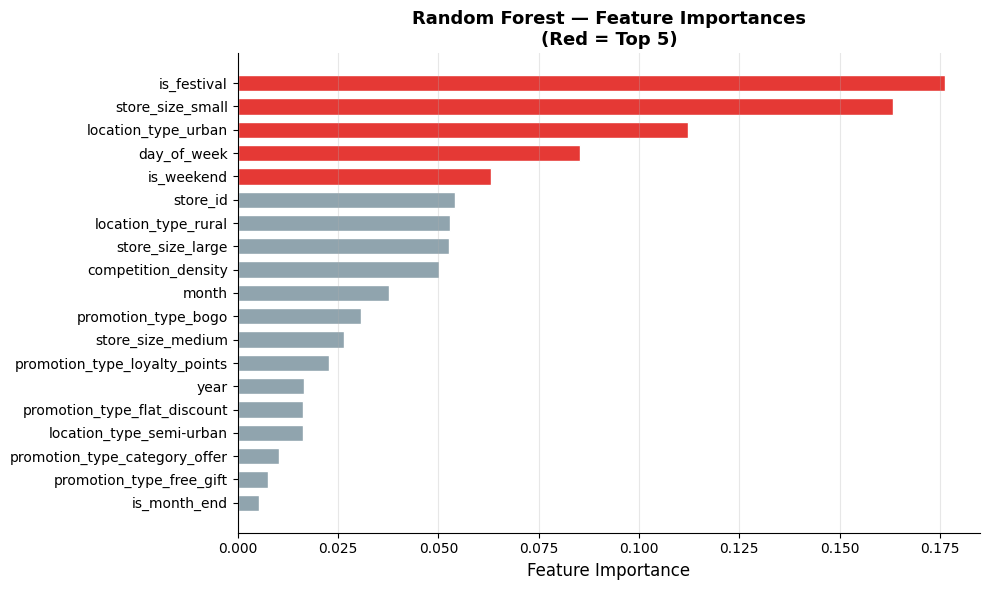

Feature importance chart saved to feature_importances.png


In [9]:
# ── 4f. Feature Importance Bar Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E53935' if i < 5 else '#90A4AE' for i in range(len(feat_imp_df))]
bars   = ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
                 color=colors[::-1], edgecolor='white', height=0.7)

ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest — Feature Importances\n(Red = Top 5)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved to feature_importances.png')